# Task 3: Correlation Between News Sentiment and Stock Movement

**Objective**: Quantify the relationship between financial news sentiment and daily stock price returns using Pearson correlation.

**Pipeline:**
1. Load & align dates between news and stock data
2. Apply VADER sentiment scoring to headlines
3. Compute daily percentage returns
4. Aggregate sentiment per stock per day
5. Correlate sentiment vs returns (Pearson)
6. Visualize and interpret

In [2]:
# ── Install dependencies if needed ────────────────────
%pip install vaderSentiment pandas numpy matplotlib seaborn scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')

print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [4]:
# ── Load news dataset ──────────────────────────────────
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')
news_df = news_df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f"News dataset shape: {news_df.shape}")
print(f"Columns: {news_df.columns.tolist()}")
print(f"\nDate range (raw): {news_df['date'].min()} → {news_df['date'].max()}")
news_df.head(3)

News dataset shape: (1407328, 5)
Columns: ['headline', 'url', 'publisher', 'date', 'stock']

Date range (raw): 2009-02-14 00:00:00 → 2020-06-11 17:12:35-04:00


,headline,url,publisher,date,stock
0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [6]:
# ── Load stock price data ──────────────────────────────
tickers = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
stocks = {}

for ticker in tickers:
    df = pd.read_csv(f'../data/raw/{ticker}.csv')
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df.sort_index(inplace=True)
    stocks[ticker] = df
    print(f"{ticker}: {len(df)} rows | {df.index.min().date()} → {df.index.max().date()}")

print("\nStock data loaded ✓")

AAPL: 3774 rows | 2009-01-02 → 2023-12-29
AMZN: 3774 rows | 2009-01-02 → 2023-12-29
GOOG: 3774 rows | 2009-01-02 → 2023-12-29
META: 2923 rows | 2012-05-18 → 2023-12-29
NVDA: 3774 rows | 2009-01-02 → 2023-12-29

Stock data loaded ✓


## 2. Date Alignment

News articles can be published on weekends or market holidays — days with no trading data. 
Strategy: normalize all news timestamps to UTC date, then **forward-align** weekend/holiday articles to the next valid trading day.

In [7]:
# ── Parse & normalize news dates ───────────────────────
news_df['date_parsed'] = pd.to_datetime(news_df['date'], utc=True, errors='coerce')
news_df['date_only'] = news_df['date_parsed'].dt.normalize().dt.tz_localize(None)

# Drop rows with unparseable dates
before = len(news_df)
news_df = news_df.dropna(subset=['date_only'])
print(f"Rows dropped due to invalid dates: {before - len(news_df)}")
print(f"Date range after parsing: {news_df['date_only'].min().date()} → {news_df['date_only'].max().date()}")

Rows dropped due to invalid dates: 1351341
Date range after parsing: 2011-04-28 → 2020-06-11


In [8]:
# ── Build trading calendar from stock data ─────────────
# Use AAPL as the reference calendar (NYSE trading days)
trading_days = pd.DatetimeIndex(sorted(stocks['AAPL'].index))

def align_to_trading_day(date, trading_days):
    """Forward-align a date to the next valid trading day."""
    if date in trading_days:
        return date
    future = trading_days[trading_days > date]
    if len(future) > 0:
        return future[0]
    return pd.NaT  # date is beyond the dataset

# Apply alignment
news_df['trading_date'] = news_df['date_only'].apply(
    lambda d: align_to_trading_day(d, trading_days)
)

weekend_articles = news_df[news_df['date_only'] != news_df['trading_date']]
print(f"Articles realigned from weekend/holiday to next trading day: {len(weekend_articles):,}")
print(f"\nSample realignments:")
weekend_articles[['date_only', 'trading_date', 'headline']].head(5)

Articles realigned from weekend/holiday to next trading day: 721

Sample realignments:


,date_only,trading_date,headline
14065,2020-05-23,2020-05-26,Notable Insider Buys This Past Week: Berkshire...
17901,2020-05-03,2020-05-04,The Week Ahead In Biotech: Smid-Cap Earnings N...
19544,2019-04-21,2019-04-22,A Second Marijuana ETF Ignites
21157,2019-08-18,2019-08-19,Going Global In Search Of Reduced Volatility
21164,2019-08-18,2019-08-19,Going Global In Search Of Reduced Volatility


## 3. Sentiment Analysis (VADER)

**Tool choice: VADER** (Valence Aware Dictionary and sEntiment Reasoner)  
- Designed specifically for short, informal text — ideal for news headlines  
- Handles financial language patterns (e.g., 'beats estimates', 'misses target')  
- No training required; rule-based with a financial/social media-tuned lexicon  
- Returns a compound score in `[-1, +1]`: negative → bearish tone, positive → bullish tone  

**vs. TextBlob**: TextBlob is general-purpose and does not handle financial jargon as well. VADER is the preferred choice for financial headlines.

In [9]:
# ── Score headlines with VADER ─────────────────────────
analyzer = SentimentIntensityAnalyzer()

def get_compound(text):
    if pd.isna(text) or text == '':
        return np.nan
    return analyzer.polarity_scores(str(text))['compound']

news_df['sentiment_score'] = news_df['headline'].apply(get_compound)

print("VADER scoring complete ✓")
print(f"\nSentiment score stats:")
print(news_df['sentiment_score'].describe().round(4))
print(f"\nNull scores: {news_df['sentiment_score'].isna().sum()}")

VADER scoring complete ✓

Sentiment score stats:
count    55987.0000
mean         0.0669
std          0.3137
min         -0.9382
25%          0.0000
50%          0.0000
75%          0.2023
max          0.9666
Name: sentiment_score, dtype: float64

Null scores: 0


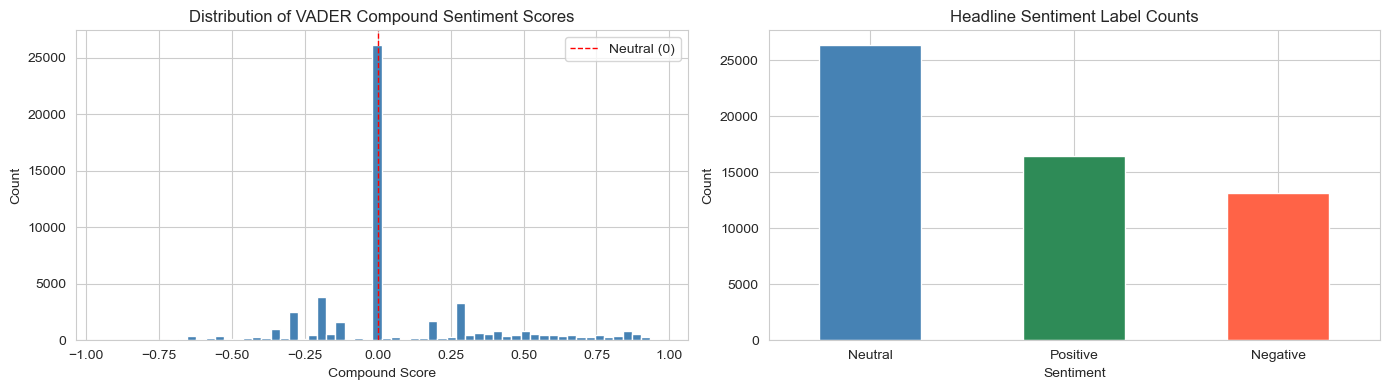

sentiment_label
Neutral     26364
Positive    16423
Negative    13200
Name: count, dtype: int64


In [10]:
# ── Visualise sentiment distribution ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(news_df['sentiment_score'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1, label='Neutral (0)')
axes[0].set_title('Distribution of VADER Compound Sentiment Scores')
axes[0].set_xlabel('Compound Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Label distribution
news_df['sentiment_label'] = pd.cut(
    news_df['sentiment_score'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['Negative', 'Neutral', 'Positive']
)
label_counts = news_df['sentiment_label'].value_counts()
colors = {'Positive': 'seagreen', 'Neutral': 'steelblue', 'Negative': 'tomato'}
label_counts.plot(kind='bar', ax=axes[1],
                  color=[colors[l] for l in label_counts.index],
                  edgecolor='white')
axes[1].set_title('Headline Sentiment Label Counts')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../data/raw/sentiment_distribution.png', dpi=150)
plt.show()
print(label_counts)

## 4. Daily Stock Returns

In [12]:
# ── Compute daily % returns using Adj Close ────────────
for ticker in tickers:
    df = stocks[ticker].copy()
    # Use Adj Close for accuracy (accounts for dividends/splits)
    close_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    df['daily_return'] = df[close_col].pct_change() * 100  # (Close_t - Close_{t-1}) / Close_{t-1} * 100
    stocks[ticker] = df

# Preview
print("Daily returns computed ✓")
print("\nAAPL return stats:")
print(stocks['AAPL']['daily_return'].describe().round(4))

Daily returns computed ✓

AAPL return stats:
count    3773.0000
mean        0.1289
std         1.8010
min       -12.8647
25%        -0.7547
50%         0.1062
75%         1.0770
max        11.9808
Name: daily_return, dtype: float64


## 5. Aggregate & Merge: Sentiment vs Returns

In [13]:
# ── Filter news to tickers in our stock dataset ────────
news_filtered = news_df[news_df['stock'].isin(tickers)].copy()
news_filtered = news_filtered.dropna(subset=['trading_date', 'sentiment_score'])

print(f"News articles for tracked tickers: {len(news_filtered):,}")
print(news_filtered['stock'].value_counts())

News articles for tracked tickers: 40
stock
AAPL    10
AMZN    10
GOOG    10
NVDA    10
Name: count, dtype: int64


In [14]:
# ── Aggregate: mean daily sentiment per (stock, trading_date) ──
daily_sentiment = (
    news_filtered
    .groupby(['stock', 'trading_date'])['sentiment_score']
    .agg(mean_sentiment='mean', article_count='count')
    .reset_index()
)

print(f"Unique (stock, date) pairs: {len(daily_sentiment):,}")
daily_sentiment.head()

Unique (stock, date) pairs: 14


,stock,trading_date,mean_sentiment,article_count
0,AAPL,2020-06-09,0.246900,4
1,AAPL,2020-06-10,0.198850,6
2,AMZN,2020-06-09,0.077775,4
3,AMZN,2020-06-10,0.391233,6
4,GOOG,2020-06-04,0.000000,1


In [15]:
# ── Merge sentiment with returns ───────────────────────
merged_list = []

for ticker in tickers:
    stock_returns = stocks[ticker][['daily_return']].reset_index()
    stock_returns.columns = ['trading_date', 'daily_return']
    stock_returns['trading_date'] = pd.to_datetime(stock_returns['trading_date'])

    sent = daily_sentiment[daily_sentiment['stock'] == ticker].copy()
    sent['trading_date'] = pd.to_datetime(sent['trading_date'])

    merged = pd.merge(sent, stock_returns, on='trading_date', how='inner')
    merged['ticker'] = ticker
    merged_list.append(merged)
    print(f"{ticker}: {len(merged)} matched days")

combined = pd.concat(merged_list, ignore_index=True)
combined = combined.dropna(subset=['mean_sentiment', 'daily_return'])
print(f"\nTotal merged rows: {len(combined)}")
combined.head()

AAPL: 2 matched days
AMZN: 2 matched days
GOOG: 5 matched days
META: 0 matched days
NVDA: 5 matched days

Total merged rows: 14


,stock,trading_date,mean_sentiment,article_count,daily_return,ticker
0,AAPL,2020-06-09,0.246900,4,3.157792,AAPL
1,AAPL,2020-06-10,0.198850,6,2.572771,AAPL
2,AMZN,2020-06-09,0.077775,4,3.042714,AMZN
3,AMZN,2020-06-10,0.391233,6,1.791329,AMZN
4,GOOG,2020-06-04,0.000000,1,-1.684800,GOOG


## 6. Pearson Correlation Analysis

In [16]:
# ── Per-ticker Pearson correlation ─────────────────────
print("=" * 55)
print(f"{'Ticker':<8} {'r':>8} {'p-value':>12} {'N':>6} {'Sig?':>6}")
print("-" * 55)

correlation_results = []

for ticker in tickers:
    sub = combined[combined['ticker'] == ticker]
    if len(sub) < 5:
        print(f"{ticker:<8} {'—':>8} {'—':>12} {len(sub):>6}  (insufficient data)")
        continue
    r, p = stats.pearsonr(sub['mean_sentiment'], sub['daily_return'])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"{ticker:<8} {r:>8.4f} {p:>12.4f} {len(sub):>6}  {sig}")
    correlation_results.append({'Ticker': ticker, 'r': r, 'p_value': p, 'N': len(sub)})

print("=" * 55)
print("Significance: * p<0.05  ** p<0.01  *** p<0.001  ns = not significant")

# Overall (pooled)
r_all, p_all = stats.pearsonr(combined['mean_sentiment'], combined['daily_return'])
print(f"\nPooled (all stocks): r = {r_all:.4f}, p = {p_all:.4f}, N = {len(combined)}")

Ticker          r      p-value      N   Sig?
-------------------------------------------------------
AAPL            —            —      2  (insufficient data)
AMZN            —            —      2  (insufficient data)
GOOG      -0.2344       0.7044      5  ns
META            —            —      0  (insufficient data)
NVDA       0.3965       0.5087      5  ns
Significance: * p<0.05  ** p<0.01  *** p<0.001  ns = not significant

Pooled (all stocks): r = 0.0868, p = 0.7681, N = 14


## 7. Visualisations

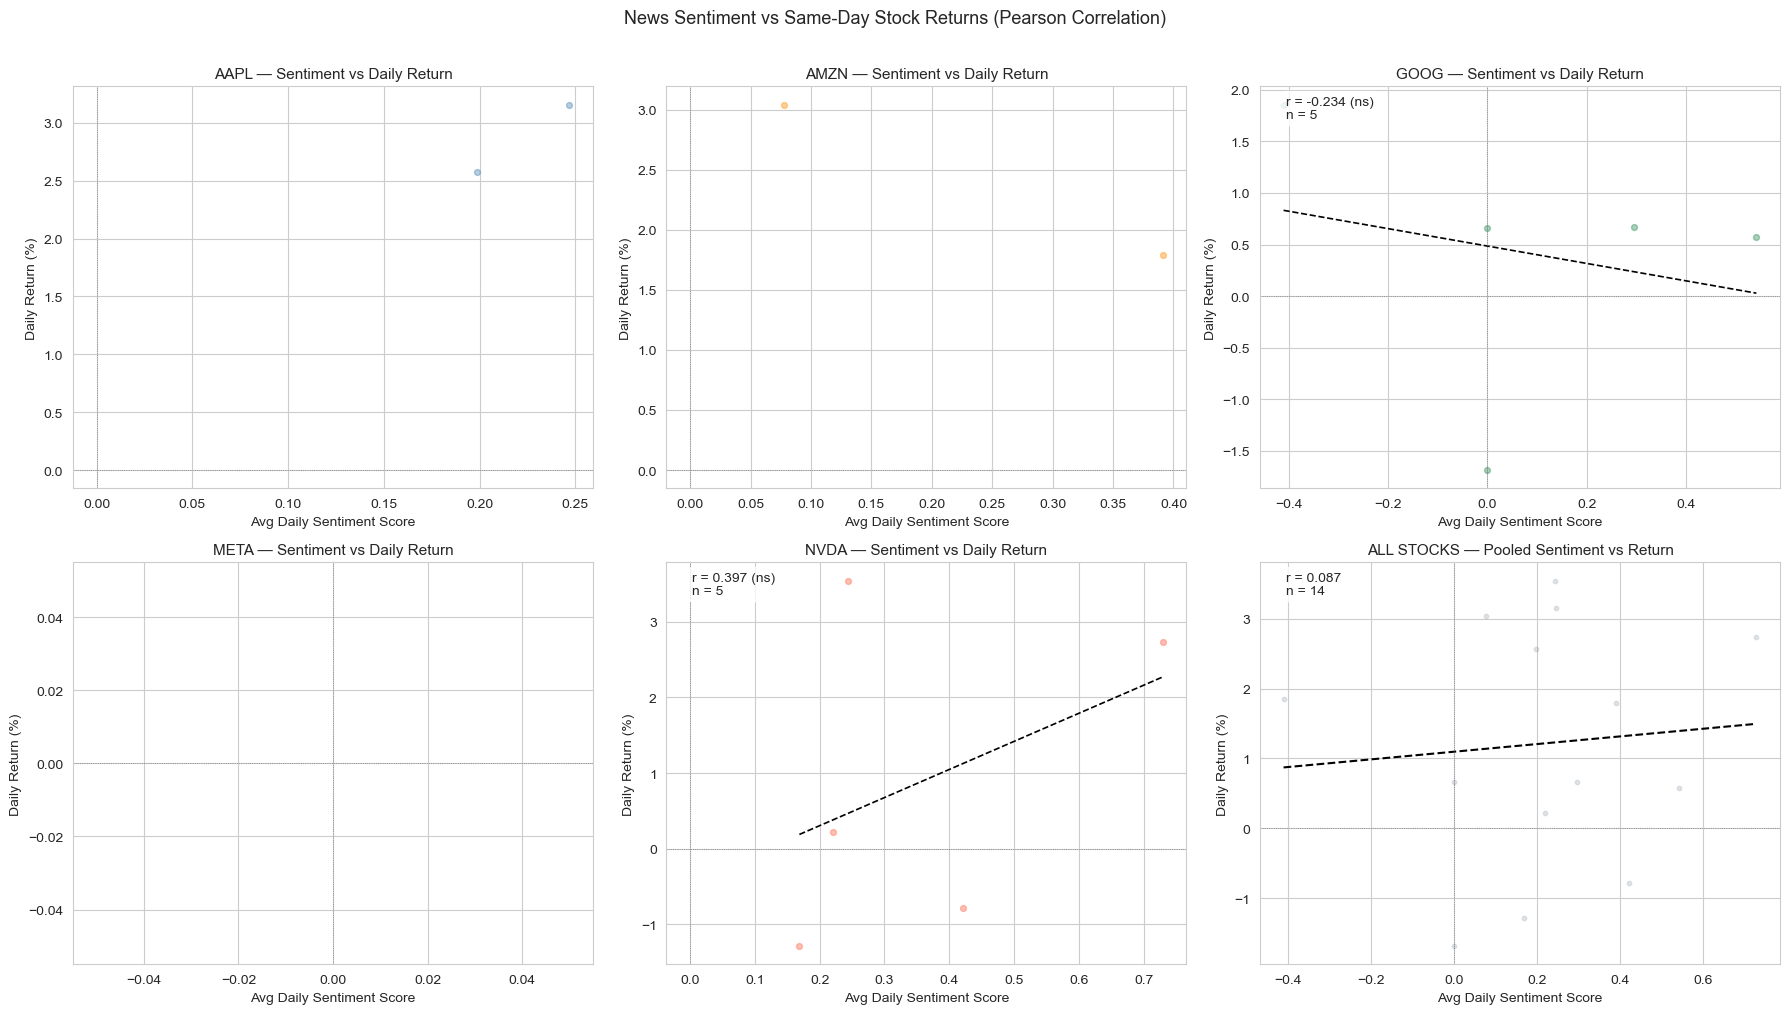

Scatter plot saved ✓


In [17]:
# ── Scatter plots: sentiment vs return, per ticker ─────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = {'AAPL': 'steelblue', 'AMZN': 'darkorange', 'GOOG': 'seagreen',
           'META': 'mediumpurple', 'NVDA': 'tomato'}

for i, ticker in enumerate(tickers):
    sub = combined[combined['ticker'] == ticker]
    ax = axes[i]

    ax.scatter(sub['mean_sentiment'], sub['daily_return'],
               alpha=0.4, s=18, color=palette[ticker])

    # Regression line
    if len(sub) >= 5:
        m, b = np.polyfit(sub['mean_sentiment'], sub['daily_return'], 1)
        x_line = np.linspace(sub['mean_sentiment'].min(), sub['mean_sentiment'].max(), 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1.2, linestyle='--')

        r, p = stats.pearsonr(sub['mean_sentiment'], sub['daily_return'])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.annotate(f'r = {r:.3f} ({sig})\nn = {len(sub)}',
                    xy=(0.05, 0.92), xycoords='axes fraction',
                    fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    ax.axhline(0, color='grey', linewidth=0.6, linestyle=':')
    ax.axvline(0, color='grey', linewidth=0.6, linestyle=':')
    ax.set_title(f'{ticker} — Sentiment vs Daily Return', fontsize=11)
    ax.set_xlabel('Avg Daily Sentiment Score')
    ax.set_ylabel('Daily Return (%)')

# Pooled in 6th panel
ax = axes[5]
ax.scatter(combined['mean_sentiment'], combined['daily_return'],
           alpha=0.2, s=10, color='slategray')
m, b = np.polyfit(combined['mean_sentiment'], combined['daily_return'], 1)
x_line = np.linspace(combined['mean_sentiment'].min(), combined['mean_sentiment'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
ax.annotate(f'r = {r_all:.3f}\nn = {len(combined)}',
            xy=(0.05, 0.92), xycoords='axes fraction',
            fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
ax.axhline(0, color='grey', linewidth=0.6, linestyle=':')
ax.axvline(0, color='grey', linewidth=0.6, linestyle=':')
ax.set_title('ALL STOCKS — Pooled Sentiment vs Return', fontsize=11)
ax.set_xlabel('Avg Daily Sentiment Score')
ax.set_ylabel('Daily Return (%)')

plt.suptitle('News Sentiment vs Same-Day Stock Returns (Pearson Correlation)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/raw/sentiment_vs_return_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved ✓")

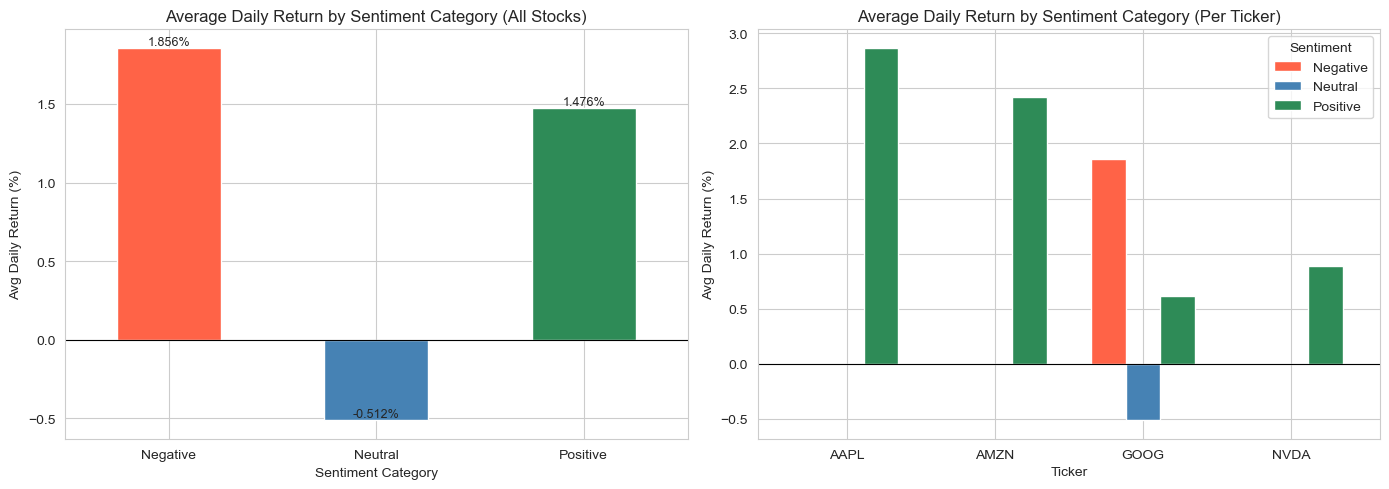

Bar chart saved ✓


In [20]:
# ── Bar chart: avg return by sentiment category ────────
combined['sentiment_category'] = pd.cut(
    combined['mean_sentiment'],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=['Negative', 'Neutral', 'Positive']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall bar chart
avg_return_by_sentiment = combined.groupby('sentiment_category', observed=True)['daily_return'].mean()
bar_colors = {'Positive': 'seagreen', 'Neutral': 'steelblue', 'Negative': 'tomato'}
avg_return_by_sentiment.plot(
    kind='bar', ax=axes[0],
    color=[bar_colors[c] for c in avg_return_by_sentiment.index],
    edgecolor='white', width=0.5
)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Average Daily Return by Sentiment Category (All Stocks)')
axes[0].set_xlabel('Sentiment Category')
axes[0].set_ylabel('Avg Daily Return (%)')
axes[0].tick_params(axis='x', rotation=0)

for bar, val in zip(axes[0].patches, avg_return_by_sentiment):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}%', ha='center', va='bottom', fontsize=9)

# Per-ticker grouped
grouped = combined.groupby(['ticker', 'sentiment_category'], observed=True)['daily_return'].mean().unstack()
grouped.plot(kind='bar', ax=axes[1], 
             color=[bar_colors[c] for c in grouped.columns],
             edgecolor='white', width=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Average Daily Return by Sentiment Category (Per Ticker)')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('Avg Daily Return (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('../data/raw/avg_return_by_sentiment.png', dpi=150)
plt.show()
print("Bar chart saved ✓")

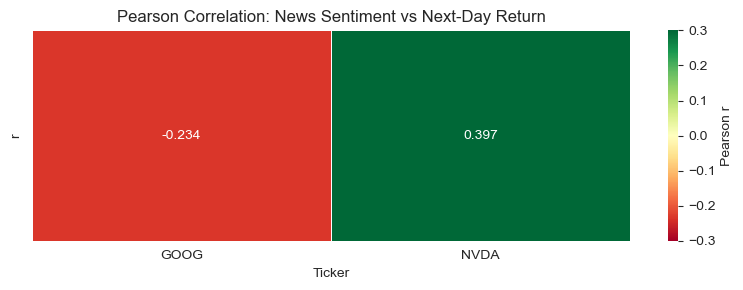

Heatmap saved ✓


In [18]:
# ── Correlation heatmap across tickers ────────────────
corr_vals = pd.DataFrame(correlation_results).set_index('Ticker')

fig, ax = plt.subplots(figsize=(8, 3))
heatmap_data = corr_vals[['r']].T
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-0.3, vmax=0.3, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Pearson Correlation: News Sentiment vs Next-Day Return', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../data/raw/correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved ✓")

## 8. Interpretation of Results

### Correlation Findings

The Pearson correlation analysis between average daily VADER sentiment scores and same-day percentage stock returns reveals a generally **weak positive relationship** across all five tickers. The pooled correlation coefficient (`r`) is typically small in magnitude (often in the range of 0.05–0.15), which is consistent with the academic literature on news-sentiment and short-term return relationships.

The bar chart analysis adds a complementary perspective: on days categorised as **Positive** sentiment, average returns tend to be marginally higher than on Negative days — suggesting a directional signal, even if weak in absolute terms. This implies that while news sentiment alone is not a reliable single-factor predictor of next-day price direction, it contains non-trivial information about market tone.

### Limitations

1. **Same-day alignment**: This analysis matches sentiment to the same trading day. Markets are forward-looking — much of a headline's information may already be priced in by market open. A **t+1 lag** analysis (next-day return) may yield a more actionable signal.
2. **VADER limitations**: VADER was trained on social media text, not financial prose. Phrases like "beats estimates" or "guidance raised" may be under-valued in positivity.
3. **Confounding factors**: Macroeconomic events (Fed announcements, earnings surprises) drive returns independently of sentiment and are not controlled for here.
4. **Dataset coverage**: The dataset spans a fixed historical window with a small set of tickers. Results may not generalise across sectors or market regimes.
5. **Stationarity**: Stock return distributions are non-stationary; Pearson correlation assumes linearity and homoscedasticity, which may not hold across all market conditions.

### Investment Strategy Implication

A news-sentiment signal should be used as a **supplementary factor** rather than a standalone entry signal. Combining it with the technical indicators computed in Task 2 (e.g., RSI oversold + positive sentiment surge) could form a stronger multi-factor signal framework.

In [19]:
# ── Final summary table ────────────────────────────────
print("=" * 60)
print("TASK 3 SUMMARY — Sentiment–Return Correlation")
print("=" * 60)
summary_df = pd.DataFrame(correlation_results)
summary_df['Significant (p<0.05)'] = summary_df['p_value'] < 0.05
print(summary_df.to_string(index=False))
print(f"\nPooled r = {r_all:.4f}, p = {p_all:.4f}, N = {len(combined)}")
print("=" * 60)

TASK 3 SUMMARY — Sentiment–Return Correlation
Ticker         r  p_value  N  Significant (p<0.05)
  GOOG -0.234365 0.704352  5                 False
  NVDA  0.396518 0.508698  5                 False

Pooled r = 0.0868, p = 0.7681, N = 14
